In [44]:
from typing import TypedDict
from langgraph.graph import StateGraph, START, END
from langchain_google_genai import ChatGoogleGenerativeAI
from dotenv import load_dotenv

In [45]:
load_dotenv()

True

In [46]:
class ParentState(TypedDict):

    question: str
    answer_eng: str
    answer_hin: str

In [47]:
parent_llm = ChatGoogleGenerativeAI(model="gemini-2.5-flash-lite")
subgraph_llm = ChatGoogleGenerativeAI(model="gemini-2.5-flash-lite")

In [48]:
def translate_text(state: ParentState):

    prompt = f"""
Translate the following text to Hindi.
Keep it natural and clear. Do not add extra content.

Text:
{state["answer_eng"]}
""".strip()
    
    translated_text = subgraph_llm.invoke(prompt).content

    return {'answer_hin': translated_text}

In [49]:
subgraph_builder = StateGraph(ParentState)

subgraph_builder.add_node('translate_text', translate_text)

subgraph_builder.add_edge(START, 'translate_text')
subgraph_builder.add_edge('translate_text', END)

subgraph = subgraph_builder.compile()

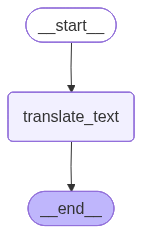

In [50]:
subgraph

In [51]:
def generate_answer(state: ParentState):

    answer = parent_llm.invoke(f"You are a helpful assistant. Answer clearly.\n\nQuestion: {state['question']}").content
    return {'answer_eng': answer}

In [52]:
parent_builder = StateGraph(ParentState)

parent_builder.add_node("answer", generate_answer)
parent_builder.add_node("translate", subgraph)

parent_builder.add_edge(START, 'answer')
parent_builder.add_edge('answer', 'translate')
parent_builder.add_edge('translate', END)

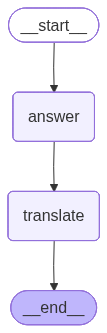

In [53]:
graph = parent_builder.compile()

graph

In [54]:
graph.invoke({'question': 'What is shared state in langgraph? answer in 3-4 lines'})

{'question': 'What is shared state in langgraph? answer in 3-4 lines',
 'answer_eng': "In LangGraph, **shared state** refers to data that is accessible and modifiable by multiple nodes (functions or agents) within the graph. It's the common pool of information that allows different parts of your agent to communicate and build upon each other's work. This state can include things like a user's query, intermediate thoughts, generated content, or any other data relevant to the agent's task.",
 'answer_hin': 'LangGraph में, **साझा स्थिति (shared state)** ऐसे डेटा को संदर्भित करती है जो ग्राफ़ के भीतर कई नोड्स (फ़ंक्शन या एजेंट) द्वारा सुलभ और संशोधनीय होती है। यह जानकारी का सामान्य पूल है जो आपके एजेंट के विभिन्न हिस्सों को संवाद करने और एक-दूसरे के काम पर निर्माण करने की अनुमति देता है। इस स्थिति में उपयोगकर्ता की क्वेरी, मध्यवर्ती विचार, उत्पन्न सामग्री, या एजेंट के कार्य से संबंधित कोई अन्य डेटा शामिल हो सकता है।'}